In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
import numpy as np
import seaborn as sns
from matplotlib.patches import Patch
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
import contextily as cx
from shapely.geometry import box
from matplotlib.ticker import FormatStrFormatter

In [2]:
# --------------- Paths ---------------
extended_dataset_dir=Path(f"../../1_preparing_data/2_us_127_basins/data/time_series")
data_camels=Path("/inputs/basin_dataset_public_v1p2/basin_mean_forcing/daymet") #camels
data_caravan=Path("/inputs/data_updated_2/time_series")
location_file = Path('../../1_preparing_data/2_us_127_basins/data/attributes/attributes_other.csv')
basins_path = Path("../../1_preparing_data/2_us_127_basins/basins_subset_test.txt")
ATTRIBUTES_FILE = Path('../../1_preparing_data/2_us_127_basins/data/attributes/attributes_caravan.csv')
data_caravan_2=Path("../../1_preparing_data/2_us_127_basins/data/time_series")
test_metrics = Path("../../2_final_runs/2_us_127_basins/ensemble_testing_metrics")



In [3]:
def plot_precipitation_comparison(
    basin: str,
    extended_dataset_dir: Path,
    data_caravan: Path,
    data_camels: Path,
    start_date: str = "1989-10-01",
    end_date: str = "2014-09-30",
    vmax_heatmap: float = 7.0,
    save_path: Path = None,
):
    """
    Plot precipitation comparison for a single basin across four products:
    CARAVAN, CAMELS (gauge), CHIRPS, and MSWEP.

    Parameters
    ----------
    basin : str
        Basin ID, e.g. "camels_us_01013500"
    extended_dataset_dir : Path
        Directory containing extended NetCDF files (with CHIRPS/MSWEP).
    data_caravan : Path
        Directory containing original Caravan NetCDF files.
    data_camels : Path
        Directory containing CAMELS gauge txt files.
    start_date : str
        Start of analysis period (inclusive), default "1989-10-01".
    end_date : str
        End of analysis period (inclusive), default "2008-09-30".
    vmax_heatmap : float
        Max value for the seasonal heatmap colorbar, default 7.
    save_path : Path, optional
        If provided, saves the figure to this path instead of showing it.
    """
    number = basin.split("_")[-1]

    # ------------------------------------------------------------------ #
    # Load data
    # ------------------------------------------------------------------ #
    camels_nc = xr.open_dataset(extended_dataset_dir / f"{basin}.nc")
    
    csv_files = list(data_camels.glob(f"**/{number}*.txt"))
    if not csv_files:
        print(f"No gauge CSV found for {basin} — skipping.")
        return
    
    df_gauge = pd.read_csv(csv_files[0], skiprows=3, sep=r"\s+")
    df_gauge["date"] = pd.to_datetime(
        df_gauge[["Year", "Mnth", "Day"]].rename(
            columns={"Year": "year", "Mnth": "month", "Day": "day"}
        )
    )
    df_gauge = df_gauge.set_index("date")

    # ------------------------------------------------------------------ #
    # Build xarray DataArrays
    # ------------------------------------------------------------------ #
    precip_caravan = camels_nc["total_precipitation_sum"]
    precip_chirpsv3  = camels_nc["chirps_precipitation"]
    precip_mswep   = camels_nc["mswep_precipitation"]
    precip_camels  = camels_nc["camels_precipitation"]

    # ------------------------------------------------------------------ #
    # Align and slice
    # ------------------------------------------------------------------ #
    precip_caravan, precip_camels, precip_chirpsv3 = xr.align(
        precip_caravan, precip_camels, precip_chirpsv3, join="inner"
    )

    t0, t1 = pd.Timestamp(start_date), pd.Timestamp(end_date)
    sl = slice(t0, t1)

    caravan = precip_caravan.sel(date=sl)
    camels  = precip_camels.sel(date=sl)
    chirps_v3  = precip_chirpsv3.sel(date=sl)
    mswep   = precip_mswep.sel(date=sl)

    # ------------------------------------------------------------------ #
    # Cumulative sums
    # ------------------------------------------------------------------ #
    cum_caravan = caravan.cumsum(dim="date").values.flatten()
    cum_camels  = camels.cumsum(dim="date").values.flatten()
    cum_chirpsv3  = chirps_v3.cumsum(dim="date").values.flatten()
    cum_mswep   = mswep.cumsum(dim="date").values.flatten()

    # ------------------------------------------------------------------ #
    # Flow duration curve helpers
    # ------------------------------------------------------------------ #
    def _fdc(da):
        arr = da.values.flatten()
        arr = arr[~np.isnan(arr)]
        arr_sorted = np.sort(arr)[::-1]
        ep = np.arange(1, len(arr_sorted) + 1) / (len(arr_sorted) + 1) * 100
        arr_plot = np.where(arr_sorted == 0, 1e-5, arr_sorted)
        return ep, arr_plot

    ep_caravan, pr_caravan_plot = _fdc(caravan)
    ep_camels,  pr_camels_plot  = _fdc(camels)
    ep_chirps_v3,  pr_chirps_v3_plot  = _fdc(chirps_v3)
    ep_mswep,   pr_mswep_plot   = _fdc(mswep)

    # ------------------------------------------------------------------ #
    # Dry spell lengths
    # ------------------------------------------------------------------ #
    def _dry_lengths(da):
        mask = (da.values.flatten() == 0)
        diff = np.diff(mask.astype(int))
        starts = np.where(diff == 1)[0] + 1
        ends   = np.where(diff == -1)[0] + 1
        if mask[0]:  starts = np.r_[0, starts]
        if mask[-1]: ends   = np.r_[ends, len(mask)]
        return ends - starts

    dry_caravan = _dry_lengths(caravan)
    dry_camels  = _dry_lengths(camels)
    dry_chirps_v3  = _dry_lengths(chirps_v3)
    dry_mswep   = _dry_lengths(mswep)

    bins = np.arange(1, max(dry_caravan.max(), dry_camels.max(),
                            dry_chirps_v3.max()) + 2) - 0.5

    # ------------------------------------------------------------------ #
    # Seasonal cycle (median by DOY)
    # ------------------------------------------------------------------ #
    dates = pd.to_datetime(caravan.date.values)
    df_doy = pd.DataFrame({
        "doy":     dates.dayofyear,
        "caravan": caravan.values,
        "camels":  camels.values,
        "chirps_v3":  chirps_v3.values,
        "mswep":   mswep.values,
    })

    def _median_doy(col):
        med = df_doy.groupby("doy")[col].median().values
        return med[:365] if len(med) == 366 else med

    all_precip = np.array([
        _median_doy("caravan"),
        _median_doy("camels"),
        _median_doy("chirps_v3"),
        _median_doy("mswep"),
    ])

    # ------------------------------------------------------------------ #
    # Plot
    # ------------------------------------------------------------------ #
    fig, ax = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle(f"Basin: {basin} - NSE drop: 0.577", fontsize=13, fontweight="bold")

    # A) Cumulative
    dates = pd.to_datetime(caravan.date.values)

    ax[0, 0].plot(dates, cum_caravan, label="CARAVAN")
    ax[0, 0].plot(dates, cum_camels,  label="CAMELS")
    ax[0, 0].plot(dates, cum_chirpsv3,  label="CHIRPS")
    ax[0, 0].plot(dates, cum_mswep,   label="MSWEP")
    ax[0, 0].set(xlabel="Date",
                ylabel="Cumulative Precipitation (mm)",
                title="A) Cumulative Precipitation")
    ax[0, 0].legend()
    ax[0, 0].grid(True)

    # B) Flow duration curve
    for ep, pr, lbl in [
        (ep_caravan, pr_caravan_plot, "CARAVAN"),
        (ep_camels,  pr_camels_plot,  "CAMELS"),
        (ep_chirps_v3,  pr_chirps_v3_plot,  "CHIRPS"),
        (ep_mswep,   pr_mswep_plot,   "MSWEP"),
    ]:
        ax[0, 1].plot(ep, pr, lw=2, label=lbl)
    ax[0, 1].set(xlabel="Exceedance probability (%)",
                 ylabel="Daily precipitation (mm)",
                 title="B) Precipitation Duration Curve",
                 yscale="log")
    ax[0, 1].legend()
    ax[0, 1].grid(True, which="both", ls="--", alpha=0.5)
    ax[0, 1].set_ylim(bottom=1e-1)

    # C) Dry spell histogram
    for lengths, lbl in [
        (dry_caravan, "CARAVAN"),
        (dry_camels,  "CAMELS"),
        (dry_chirps_v3,  "CHIRPS"),
        (dry_mswep,   "MSWEP"),
    ]:
        ax[1, 0].hist(lengths, bins=bins, histtype="step", lw=1.5, label=lbl)
    ax[1, 0].set(xlabel="Dry spell length (days)",
                 ylabel="Frequency",
                 title="C) Histogram of Dry Period Lengths")
    ax[1, 0].legend()
    ax[1, 0].grid(True, ls="--", alpha=0.5)

    # D) Seasonal heatmap
    im = ax[1, 1].imshow(all_precip, aspect="auto", cmap="viridis",
                         vmin=0, vmax=vmax_heatmap, interpolation="nearest")
    ax[1, 1].set_yticks([0, 1, 2, 3])
    ax[1, 1].set_yticklabels(["CARAVAN", "CAMELS","CHIRPS", "MSWEP"])
    ax[1, 1].set(xlabel="Day of Year", ylabel="Product",
                 title=f"D) Median Daily Precipitation ({start_date[:4]}–{end_date[:4]})")
    plt.colorbar(im, ax=ax[1, 1]).set_label("Median Precip (mm)")

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.35, wspace=0.3)

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved: {save_path}")
    else:
        plt.show()

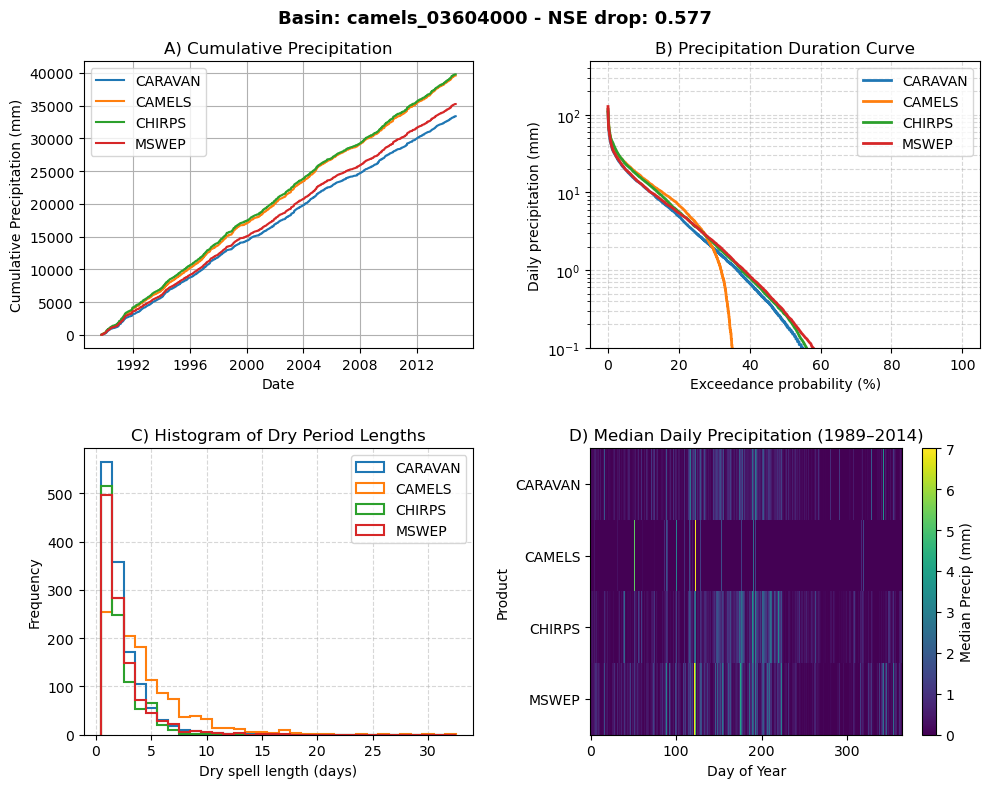

In [4]:
plot_precipitation_comparison(
        basin = "camels_03604000", #Biggest drop in NSE with no snow
        # basin="camels_05408000", #Biggest drop in NSE of the whole US
        extended_dataset_dir=extended_dataset_dir,
        data_caravan=data_caravan,
        data_camels=data_camels,
        # save_path=output_dir / f"{basin}.png",  # remove to show interactively
    )

In [5]:
def plot_precipitation_comparison_2(
    basin: str,
    extended_dataset_dir: Path,
    data_caravan: Path,
    data_camels: Path,
    start_date: str = "1989-10-01",
    end_date: str = "2014-09-30",
    vmax_heatmap: float = 7.0,
    save_path: Path = None,
):
    """
    Plot precipitation comparison for a single basin across four products:
    CARAVAN, CAMELS (gauge), CHIRPS, and MSWEP.

    Parameters
    ----------
    basin : str
        Basin ID, e.g. "camels_us_01013500"
    extended_dataset_dir : Path
        Directory containing extended NetCDF files (with CHIRPS/MSWEP).
    data_caravan : Path
        Directory containing original Caravan NetCDF files.
    data_camels : Path
        Directory containing CAMELS gauge txt files.
    start_date : str
        Start of analysis period (inclusive), default "1989-10-01".
    end_date : str
        End of analysis period (inclusive), default "2008-09-30".
    vmax_heatmap : float
        Max value for the seasonal heatmap colorbar, default 7.
    save_path : Path, optional
        If provided, saves the figure to this path instead of showing it.
    """
    number = basin.split("_")[-1]

    # ------------------------------------------------------------------ #
    # Load data
    # ------------------------------------------------------------------ #
    camels_nc = xr.open_dataset(extended_dataset_dir / f"{basin}.nc")
    
    csv_files = list(data_camels.glob(f"**/{number}*.txt"))
    if not csv_files:
        print(f"No gauge CSV found for {basin} — skipping.")
        return
    
    df_gauge = pd.read_csv(csv_files[0], skiprows=3, sep=r"\s+")
    df_gauge["date"] = pd.to_datetime(
        df_gauge[["Year", "Mnth", "Day"]].rename(
            columns={"Year": "year", "Mnth": "month", "Day": "day"}
        )
    )
    df_gauge = df_gauge.set_index("date")

    # ------------------------------------------------------------------ #
    # Build xarray DataArrays
    # ------------------------------------------------------------------ #
    precip_caravan = camels_nc["total_precipitation_sum"]
    precip_chirpsv3  = camels_nc["chirps_precipitation"]
    precip_mswep   = camels_nc["mswep_precipitation"]
    precip_camels  = camels_nc["camels_precipitation"]

    # ------------------------------------------------------------------ #
    # Align and slice
    # ------------------------------------------------------------------ #
    precip_caravan, precip_camels, precip_chirpsv3 = xr.align(
        precip_caravan, precip_camels, precip_chirpsv3, join="inner"
    )

    t0, t1 = pd.Timestamp(start_date), pd.Timestamp(end_date)
    sl = slice(t0, t1)

    caravan = precip_caravan.sel(date=sl)
    camels  = precip_camels.sel(date=sl)
    chirps_v3  = precip_chirpsv3.sel(date=sl)
    mswep   = precip_mswep.sel(date=sl)

    # ------------------------------------------------------------------ #
    # Cumulative sums
    # ------------------------------------------------------------------ #
    cum_caravan = caravan.cumsum(dim="date").values.flatten()
    cum_camels  = camels.cumsum(dim="date").values.flatten()
    cum_chirpsv3  = chirps_v3.cumsum(dim="date").values.flatten()
    cum_mswep   = mswep.cumsum(dim="date").values.flatten()

    # ------------------------------------------------------------------ #
    # Flow duration curve helpers
    # ------------------------------------------------------------------ #
    def _fdc(da):
        arr = da.values.flatten()
        arr = arr[~np.isnan(arr)]
        arr_sorted = np.sort(arr)[::-1]
        ep = np.arange(1, len(arr_sorted) + 1) / (len(arr_sorted) + 1) * 100
        arr_plot = np.where(arr_sorted == 0, 1e-5, arr_sorted)
        return ep, arr_plot

    ep_caravan, pr_caravan_plot = _fdc(caravan)
    ep_camels,  pr_camels_plot  = _fdc(camels)
    ep_chirps_v3,  pr_chirps_v3_plot  = _fdc(chirps_v3)
    ep_mswep,   pr_mswep_plot   = _fdc(mswep)

    # ------------------------------------------------------------------ #
    # Dry spell lengths
    # ------------------------------------------------------------------ #
    def _dry_lengths(da):
        mask = (da.values.flatten() < 0.1)  # dry day = precipitation below 0.1 mm
        diff = np.diff(mask.astype(int))
        starts = np.where(diff == 1)[0] + 1
        ends   = np.where(diff == -1)[0] + 1
        if mask[0]:  starts = np.r_[0, starts]
        if mask[-1]: ends   = np.r_[ends, len(mask)]
        return ends - starts

    dry_caravan = _dry_lengths(caravan)
    dry_camels  = _dry_lengths(camels)
    dry_chirps_v3  = _dry_lengths(chirps_v3)
    dry_mswep   = _dry_lengths(mswep)

    bins = np.arange(1, max(dry_caravan.max(), dry_camels.max(),
                            dry_chirps_v3.max()) + 2) - 0.5

    # ------------------------------------------------------------------ #
    # Seasonal cycle (median by DOY)
    # ------------------------------------------------------------------ #
    dates = pd.to_datetime(caravan.date.values)
    df_doy = pd.DataFrame({
        "doy":     dates.dayofyear,
        "caravan": caravan.values,
        "camels":  camels.values,
        "chirps_v3":  chirps_v3.values,
        "mswep":   mswep.values,
    })

    def _median_doy(col):
        med = df_doy.groupby("doy")[col].median().values
        return med[:365] if len(med) == 366 else med

    all_precip = np.array([
        _median_doy("caravan"),
        _median_doy("camels"),
        _median_doy("chirps_v3"),
        _median_doy("mswep"),
    ])

    # ------------------------------------------------------------------ #
    # Plot
    # ------------------------------------------------------------------ #
    fig, ax = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle(f"Basin: {basin} - NSE drop: 0.577", fontsize=13, fontweight="bold")

    # A) Cumulative
    dates = pd.to_datetime(caravan.date.values)

    ax[0, 0].plot(dates, cum_caravan, label="CARAVAN")
    ax[0, 0].plot(dates, cum_camels,  label="CAMELS")
    ax[0, 0].plot(dates, cum_chirpsv3,  label="CHIRPS")
    ax[0, 0].plot(dates, cum_mswep,   label="MSWEP")
    ax[0, 0].set(xlabel="Date",
                ylabel="Cumulative Precipitation (mm)",
                title="A) Cumulative Precipitation")
    ax[0, 0].legend()
    ax[0, 0].grid(True)

    # B) Flow duration curve
    for ep, pr, lbl in [
        (ep_caravan, pr_caravan_plot, "CARAVAN"),
        (ep_camels,  pr_camels_plot,  "CAMELS"),
        (ep_chirps_v3,  pr_chirps_v3_plot,  "CHIRPS"),
        (ep_mswep,   pr_mswep_plot,   "MSWEP"),
    ]:
        ax[0, 1].plot(ep, pr, lw=2, label=lbl)
    ax[0, 1].set(xlabel="Exceedance probability (%)",
                 ylabel="Daily precipitation (mm)",
                 title="B) Precipitation Duration Curve",
                 yscale="log")
    ax[0, 1].legend()
    ax[0, 1].grid(True, which="both", ls="--", alpha=0.5)
    ax[0, 1].set_ylim(bottom=1e-1)

    # C) Dry spell histogram
    for lengths, lbl in [
        (dry_caravan, "CARAVAN"),
        (dry_camels,  "CAMELS"),
        (dry_chirps_v3,  "CHIRPS"),
        (dry_mswep,   "MSWEP"),
    ]:
        ax[1, 0].hist(lengths, bins=bins, histtype="step", lw=1.5, label=lbl)
    ax[1, 0].set(xlabel="Dry spell length (days)",
                 ylabel="Frequency",
                 title="C) Histogram of Dry Period Lengths")
    ax[1, 0].legend()
    ax[1, 0].grid(True, ls="--", alpha=0.5)

    # D) Seasonal heatmap
    im = ax[1, 1].imshow(all_precip, aspect="auto", cmap="turbo",
                         vmin=0, vmax=vmax_heatmap, interpolation="nearest")
    ax[1, 1].set_yticks([0, 1, 2, 3])
    ax[1, 1].set_yticklabels(["CARAVAN", "CAMELS","CHIRPS", "MSWEP"])
    ax[1, 1].set(xlabel="Day of Year", ylabel="Product",
                 title=f"D) Median Daily Precipitation ({start_date[:4]}–{end_date[:4]})")
    plt.colorbar(im, ax=ax[1, 1]).set_label("Median Precip (mm)")

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.35, wspace=0.3)

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved: {save_path}")
    else:
        plt.show()

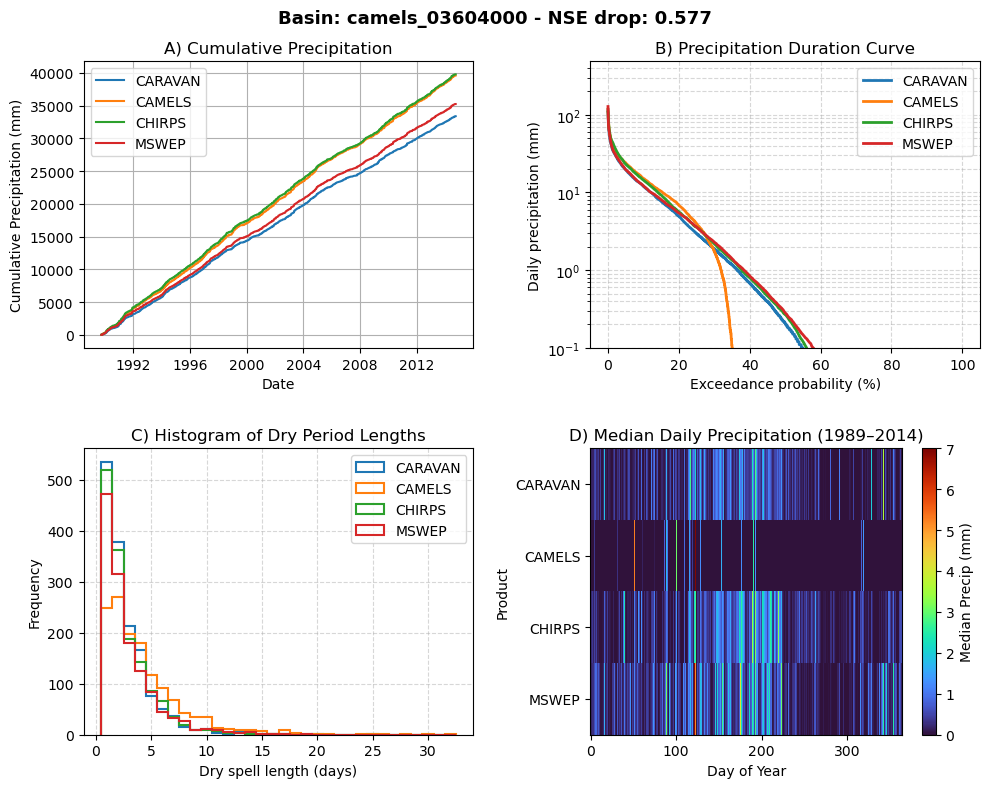

In [6]:
plot_precipitation_comparison_2(
        basin = "camels_03604000", #Biggest drop in NSE with no snow
        # basin="camels_05408000", #Biggest drop in NSE of the whole US
        extended_dataset_dir=extended_dataset_dir,
        data_caravan=data_caravan,
        data_camels=data_camels,
        # save_path=output_dir / f"{basin}.png",  # remove to show interactively
    )

In [7]:
def plot_seasonal_heatmap(
    basin: str,
    extended_dataset_dir: Path,
    start_date: str = "1989-10-01",
    end_date: str = "2014-09-30",
    vmax_heatmap: float = 6.0,
    save_path: Path = None,
):
    camels_nc = xr.open_dataset(extended_dataset_dir / f"{basin}.nc")

    sl = slice(pd.Timestamp(start_date), pd.Timestamp(end_date))
    caravan   = camels_nc["total_precipitation_sum"].sel(date=sl)
    camels    = camels_nc["camels_precipitation"].sel(date=sl)
    chirps_v3 = camels_nc["chirps_precipitation"].sel(date=sl)
    mswep     = camels_nc["mswep_precipitation"].sel(date=sl)

    dates = pd.to_datetime(caravan.date.values)
    df_doy = pd.DataFrame({
        "doy":      dates.dayofyear,
        "caravan":  caravan.values,
        "camels":   camels.values,
        "chirps_v3": chirps_v3.values,
        "mswep":    mswep.values,
    })

    def _median_doy(col):
        med = df_doy.groupby("doy")[col].median().values
        return med[:365] if len(med) == 366 else med

    all_precip = np.array([
        _median_doy("caravan"),
        _median_doy("camels"),
        _median_doy("chirps_v3"),
        _median_doy("mswep"),
    ])

    fig, ax = plt.subplots(figsize=(4, 3))
    im = ax.imshow(all_precip, aspect="auto", cmap="viridis",
                   vmin=0, vmax=vmax_heatmap, interpolation="nearest")
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(["CARAVAN", "CAMELS", "CHIRPS", "MSWEP"])
    ax.set(xlabel="Day of Year", ylabel="Product",
           title=f"Median Daily Precipitation ({start_date[:4]}–{end_date[:4]})")
    plt.colorbar(im, ax=ax).set_label("Median Precip (mm)")
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved: {save_path}")
    else:
        plt.show()

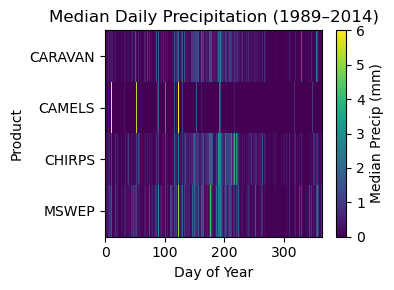

In [8]:
plot_seasonal_heatmap(
        basin = "camels_03604000", #Biggest drop in NSE with no snow
        # basin="camels_05408000", #Biggest drop in NSE of the whole US
        extended_dataset_dir=extended_dataset_dir,
        # save_path=output_dir / f"{basin}.png",  # remove to show interactively
    )

In [9]:
def plot_precipitation_comparison(
    basin: str,
    extended_dataset_dir: Path,
    data_caravan: Path,
    data_camels: Path,
    start_date: str = "1989-10-01",
    end_date: str = "2014-09-30",
    vmax_heatmap: float = 7.0,
    save_path: Path = None,
):
    """
    Plot precipitation comparison for a single basin across four products:
    CARAVAN, CAMELS (gauge), CHIRPS, and MSWEP.

    Parameters
    ----------
    basin : str
        Basin ID, e.g. "camels_us_01013500"
    extended_dataset_dir : Path
        Directory containing extended NetCDF files (with CHIRPS/MSWEP).
    data_caravan : Path
        Directory containing original Caravan NetCDF files.
    data_camels : Path
        Directory containing CAMELS gauge txt files.
    start_date : str
        Start of analysis period (inclusive), default "1989-10-01".
    end_date : str
        End of analysis period (inclusive), default "2008-09-30".
    vmax_heatmap : float
        Max value for the seasonal heatmap colorbar, default 7.
    save_path : Path, optional
        If provided, saves the figure to this path instead of showing it.
    """
    number = basin.split("_")[-1]

    # ------------------------------------------------------------------ #
    # Load data
    # ------------------------------------------------------------------ #
    camels_nc = xr.open_dataset(extended_dataset_dir / f"{basin}.nc")

    csv_files = list(data_camels.glob(f"**/{number}*.txt"))
    if not csv_files:
        print(f"No gauge CSV found for {basin} — skipping.")
        return

    df_gauge = pd.read_csv(csv_files[0], skiprows=3, sep=r"\s+")
    df_gauge["date"] = pd.to_datetime(
        df_gauge[["Year", "Mnth", "Day"]].rename(
            columns={"Year": "year", "Mnth": "month", "Day": "day"}
        )
    )
    df_gauge = df_gauge.set_index("date")

    # ------------------------------------------------------------------ #
    # Build xarray DataArrays
    # ------------------------------------------------------------------ #
    precip_caravan = camels_nc["total_precipitation_sum"]
    precip_chirps_v3  = camels_nc["chirps_precipitation"]
    precip_mswep   = camels_nc["mswep_precipitation"]
    precip_camels  = xr.DataArray(
        df_gauge["prcp(mm/day)"],
        coords={"date": df_gauge.index},
        dims="date",
        name="prcp",
    )

    # ------------------------------------------------------------------ #
    # Align and slice
    # ------------------------------------------------------------------ #
    precip_caravan, precip_camels, precip_chirps_v3 = xr.align(
        precip_caravan, precip_camels, precip_chirps_v3, join="inner"
    )

    t0, t1 = pd.Timestamp(start_date), pd.Timestamp(end_date)
    sl = slice(t0, t1)

    caravan = precip_caravan.sel(date=sl)
    camels  = precip_camels.sel(date=sl)
    chirps_v3  = precip_chirps_v3.sel(date=sl)
    mswep   = precip_mswep.sel(date=sl)

    # ------------------------------------------------------------------ #
    # Cumulative sums
    # ------------------------------------------------------------------ #
    cum_caravan = caravan.cumsum(dim="date").values.flatten()
    cum_camels  = camels.cumsum(dim="date").values.flatten()
    cum_chirps_v3  = chirps_v3.cumsum(dim="date").values.flatten()
    cum_mswep   = mswep.cumsum(dim="date").values.flatten()

    # ------------------------------------------------------------------ #
    # Flow duration curve
    # ------------------------------------------------------------------ #
    def _fdc(da):
        arr = da.values.flatten()
        arr = arr[~np.isnan(arr)]
        arr_sorted = np.sort(arr)[::-1]
        ep = np.arange(1, len(arr_sorted) + 1) / (len(arr_sorted) + 1) * 100
        arr_plot = np.where(arr_sorted == 0, 1e-5, arr_sorted)
        return ep, arr_plot

    ep_caravan, pr_caravan_plot = _fdc(caravan)
    ep_camels,  pr_camels_plot  = _fdc(camels)
    ep_chirps_v3,  pr_chirps_v3_plot  = _fdc(chirps_v3)
    ep_mswep,   pr_mswep_plot   = _fdc(mswep)

    # ------------------------------------------------------------------ #
    # Dry period lengths
    # ------------------------------------------------------------------ #
    def _dry_lengths(da):
        mask   = (da.values.flatten() == 0)
        diff   = np.diff(mask.astype(int))
        starts = np.where(diff == 1)[0] + 1
        ends   = np.where(diff == -1)[0] + 1
        if mask[0]:  starts = np.r_[0, starts]
        if mask[-1]: ends   = np.r_[ends, len(mask)]
        return ends - starts

    dry_caravan = _dry_lengths(caravan)
    dry_camels  = _dry_lengths(camels)
    dry_chirps_v3  = _dry_lengths(chirps_v3)
    dry_mswep   = _dry_lengths(mswep)

    bins = np.arange(1, max(dry_caravan.max(), dry_camels.max(),
                            dry_chirps_v3.max()) + 2) - 0.5

    # ------------------------------------------------------------------ #
    # Seasonal cycle (median and mean by DOY)
    # ------------------------------------------------------------------ #
    dates  = pd.to_datetime(caravan.date.values)
    df_doy = pd.DataFrame({
        "doy":     dates.dayofyear,
        "caravan": caravan.values,
        "camels":  camels.values,
        "chirps_v3":  chirps_v3.values,
        "mswep":   mswep.values,
    })

    def _median_doy(col):
        med = df_doy.groupby("doy")[col].median().values
        return med[:365] if len(med) == 366 else med

    def _mean_doy(col):
        mn = df_doy.groupby("doy")[col].mean().values
        return mn[:365] if len(mn) == 366 else mn

    all_precip_median = np.array([
        _median_doy("caravan"),
        _median_doy("camels"),
        _median_doy("chirps_v3"),
        _median_doy("mswep"),
    ])

    all_precip_mean = np.array([
        _mean_doy("caravan"),
        _mean_doy("camels"),
        _mean_doy("chirps_v3"),
        _mean_doy("mswep"),
    ])

    # ------------------------------------------------------------------ #
    # Plot (2×3 grid, last slot hidden)
    # ------------------------------------------------------------------ #
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"Basin: {basin}", fontsize=13, fontweight="bold")

    ax = axes

    # A) Cumulative
    dates = pd.to_datetime(caravan.date.values)

    ax[0, 0].plot(dates, cum_caravan, label="CARAVAN")
    ax[0, 0].plot(dates, cum_camels,  label="CAMELS")
    ax[0, 0].plot(dates, cum_chirps_v3,  label="CHIRPS_v3")
    ax[0, 0].plot(dates, cum_mswep,   label="MSWEP")
    ax[0, 0].set(xlabel="Date",
                ylabel="Cumulative Precipitation (mm)",
                title="A) Cumulative Precipitation")
    ax[0, 0].legend()
    ax[0, 0].grid(True)

    # B) Flow duration curve
    for ep, pr, lbl in [
        (ep_caravan, pr_caravan_plot, "CARAVAN"),
        (ep_camels,  pr_camels_plot,  "CAMELS"),
        (ep_chirps_v3,  pr_chirps_v3_plot,  "CHIRPS_v3"),
        (ep_mswep,   pr_mswep_plot,   "MSWEP"),
    ]:
        ax[0, 1].plot(ep, pr, lw=2, label=lbl)
    ax[0, 1].set(xlabel="Exceedance probability (%)",
                 ylabel="Daily precipitation (mm)",
                 title="B) Precipitation Duration Curve",
                 yscale="log")
    ax[0, 1].legend()
    ax[0, 1].grid(True, which="both", ls="--", alpha=0.5)
    ax[0, 1].set_ylim(bottom=1e-2)

    # C) Dry period histogram
    for lengths, lbl in [
        (dry_caravan, "CARAVAN"),
        (dry_camels,  "CAMELS"),
        (dry_chirps_v3,  "CHIRPS_v3"),
        (dry_mswep,   "MSWEP"),
    ]:
        ax[0, 2].hist(lengths, bins=bins, histtype="step", lw=2, label=lbl)
    ax[0, 2].set(xlabel="Dry period length (days)",
                 ylabel="Frequency",
                 title="C) Histogram of Dry Period Lengths")
    ax[0, 2].legend()
    ax[0, 2].grid(True, ls="--", alpha=0.5)

    # D) Seasonal heatmap — median
    im1 = ax[1, 0].imshow(all_precip_median, aspect="auto", cmap="viridis",
                          vmin=0, vmax=vmax_heatmap, interpolation="nearest")
    ax[1, 0].set_yticks([0, 1, 2, 3])
    ax[1, 0].set_yticklabels(["CARAVAN", "CAMELS", "CHIRPS_v3", "MSWEP"])
    ax[1, 0].set(xlabel="Day of Year", ylabel="Product",
                 title=f"D) Median Daily Precipitation ({start_date[:4]}–{end_date[:4]})")
    plt.colorbar(im1, ax=ax[1, 0]).set_label("Median Precip (mm)")

    # E) Seasonal heatmap — mean
    im2 = ax[1, 1].imshow(all_precip_mean, aspect="auto", cmap="viridis",
                          vmin=0, vmax=vmax_heatmap, interpolation="nearest")
    ax[1, 1].set_yticks([0, 1, 2, 3])
    ax[1, 1].set_yticklabels(["CARAVAN", "CAMELS", "CHIRPS_v3", "MSWEP"])
    ax[1, 1].set(xlabel="Day of Year", ylabel="Product",
                 title=f"E) Mean Daily Precipitation ({start_date[:4]}–{end_date[:4]})")
    plt.colorbar(im2, ax=ax[1, 1]).set_label("Mean Precip (mm)")

    # hide last slot
    ax[1, 2].set_visible(False)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.35, wspace=0.3)

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"Saved: {save_path}")
    else:
        plt.show()

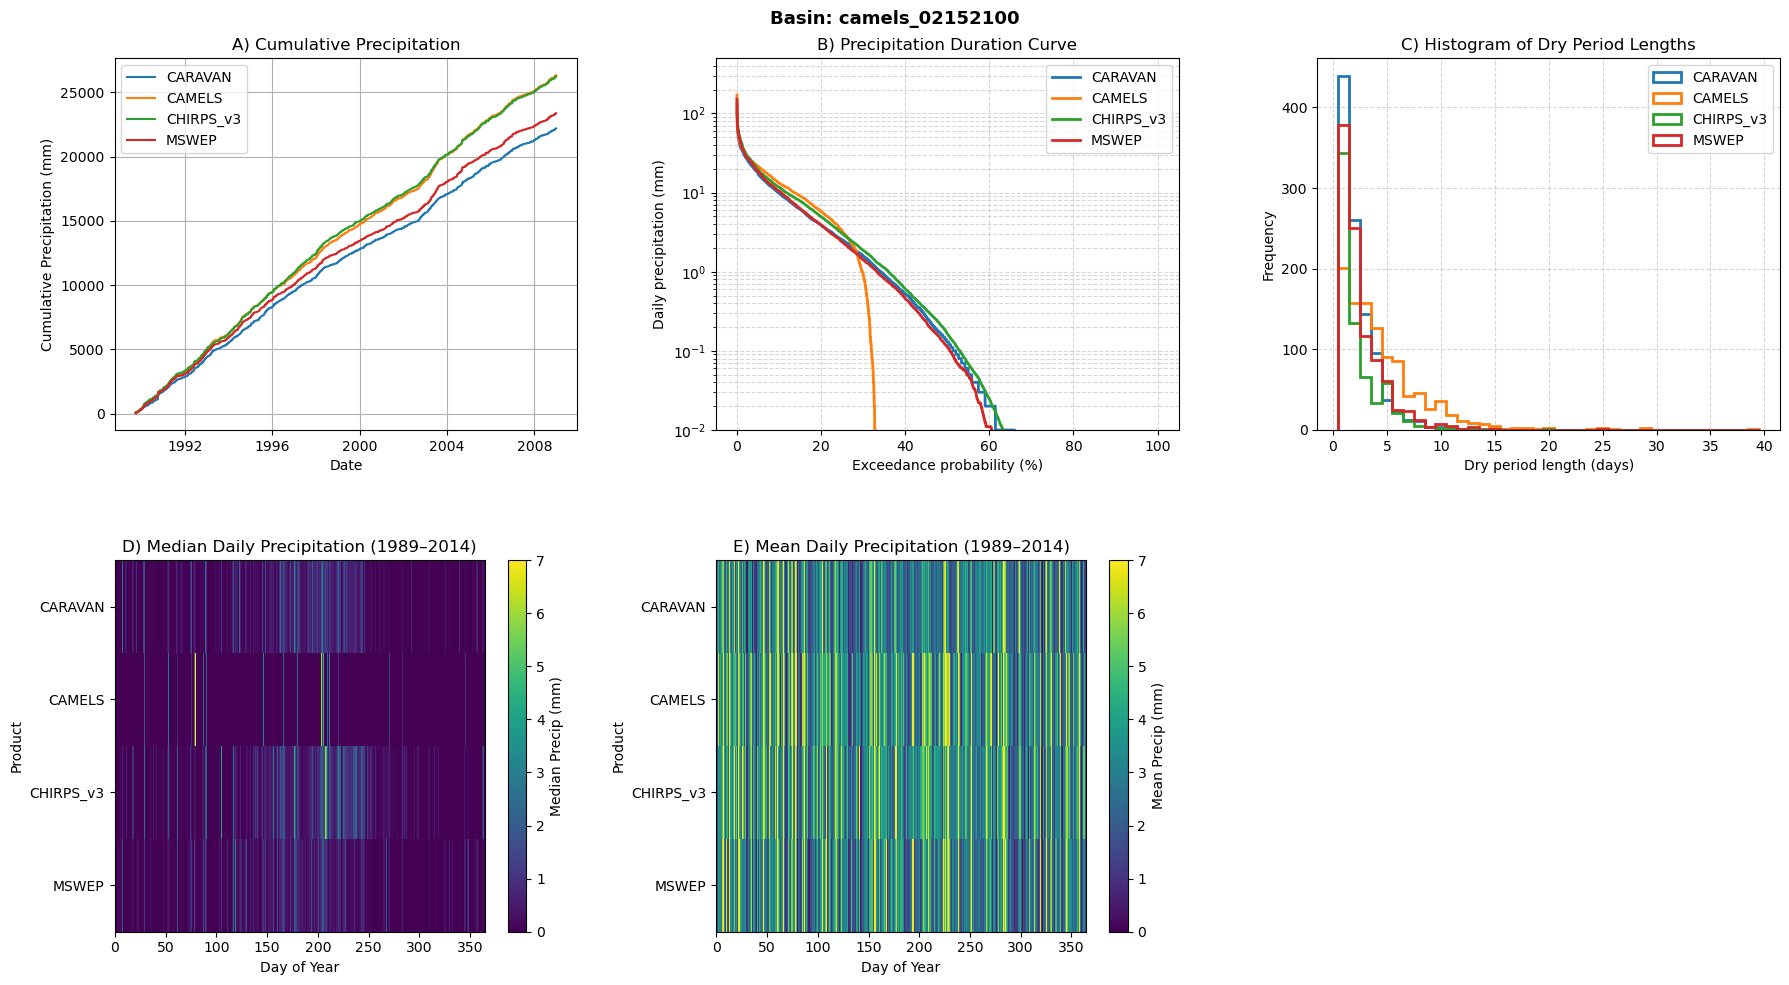

In [10]:
plot_precipitation_comparison(
        basin = "camels_02152100", #Biggest drop in NSE with no snow
        # basin="camels_05408000", #Biggest drop in NSE of the whole US
        extended_dataset_dir=extended_dataset_dir,
        data_caravan=data_caravan,
        data_camels=data_camels,
        # save_path=output_dir / f"{basin}.png",  # remove to show interactively
    )

Found 127 basins matching filter.


Processed 127 basins.


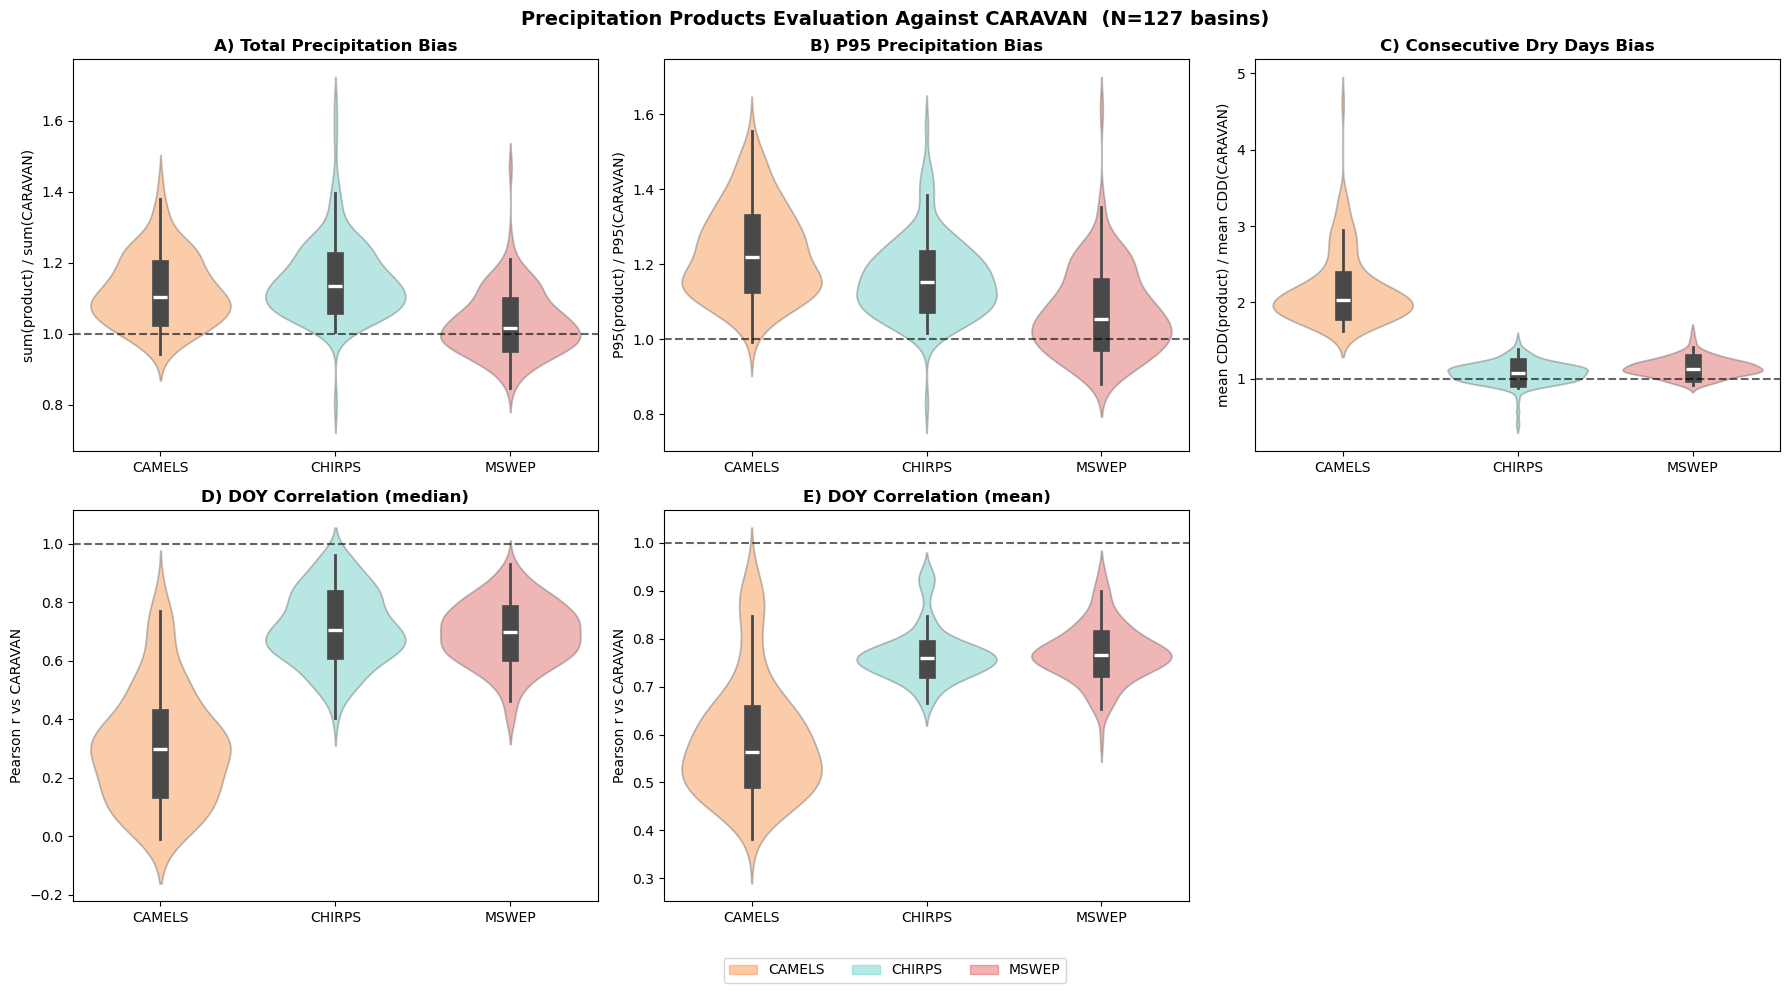

In [11]:
START_DATE = "1989-10-01"
END_DATE   = "2014-09-30"

PRODUCTS = ["CAMELS", "CHIRPS", "MSWEP"]
VAR_MAP  = {
    "CAMELS": "camels_precipitation",
    "CARAVAN": "total_precipitation_sum",
    "CHIRPS":  "chirps_precipitation",
    "MSWEP":   "mswep_precipitation",
}
PALETTE = {
    "CAMELS": "#FF6B00", #"#3A86FF",
    "CHIRPS": "#2EC4B6",
    "MSWEP":  "#DC2626",
}
# ── Metric helpers ─────────────────────────────────────────────────────────────
def volume_ratio(arr, ref):
    s = np.nansum(ref)
    return np.nansum(arr) / s if s > 0 else np.nan

def p95_ratio(arr, ref):
    p = np.nanpercentile(ref, 95)
    return np.nanpercentile(arr, 95) / p if p > 0 else np.nan

def mean_dry_spell(arr):
    arr_clean = arr[~np.isnan(arr)]
    mask   = arr_clean == 0
    diff   = np.diff(mask.astype(int))
    starts = np.where(diff ==  1)[0] + 1
    ends   = np.where(diff == -1)[0] + 1
    if mask[0]:  starts = np.r_[0, starts]
    if mask[-1]: ends   = np.r_[ends, len(mask)]
    lengths = (ends - starts)
    lengths = lengths[lengths > 0]
    return np.mean(lengths) if len(lengths) > 0 else np.nan

def dry_spell_ratio(arr, ref):
    m_ref = mean_dry_spell(ref)
    m_arr = mean_dry_spell(arr)
    return m_arr / m_ref if (m_ref and not np.isnan(m_ref) and m_ref > 0) else np.nan

def seasonal_median(arr, dates):
    df = pd.DataFrame({"doy": pd.DatetimeIndex(dates).dayofyear, "val": arr})
    med = df.groupby("doy")["val"].median()
    full = pd.Series(0.0, index=np.arange(1, 366))
    full.update(med)
    return full.values

def seasonal_corr(arr, ref, dates):
    s_ref = seasonal_median(ref, dates)
    s_arr = seasonal_median(arr, dates)
    if np.std(s_ref) == 0 or np.std(s_arr) == 0:
        return np.nan
    r, _ = pearsonr(s_ref, s_arr)
    return r

def seasonal_mean(arr, dates):
    df = pd.DataFrame({"doy": pd.DatetimeIndex(dates).dayofyear, "val": arr})
    mn = df.groupby("doy")["val"].mean()
    full = pd.Series(0.0, index=np.arange(1, 366))
    full.update(mn)
    return full.values

def seasonal_corr_mean(arr, ref, dates):
    s_ref = seasonal_mean(ref, dates)
    s_arr = seasonal_mean(arr, dates)
    if np.std(s_ref) == 0 or np.std(s_arr) == 0:
        return np.nan
    r, _ = pearsonr(s_ref, s_arr)
    return r

# ── Load gauge txt ─────────────────────────────────────────────────────────────
def load_gauge_txt(basin, data_camels):
    number    = basin.split("_")[-1]
    csv_files = list(data_camels.glob(f"**/{number}*.txt"))
    if not csv_files:
        return None
    df = pd.read_csv(csv_files[0], skiprows=3, sep=r"\s+")
    df["date"] = pd.to_datetime(
        df[["Year", "Mnth", "Day"]].rename(
            columns={"Year": "year", "Mnth": "month", "Day": "day"}
        )
    )
    return df.set_index("date")["prcp(mm/day)"]

# ── Load basin list ────────────────────────────────────────────────────────────
basins_to_use = set(basins_path.read_text().splitlines())

# ── Load all basins → tidy DataFrame ──────────────────────────────────────────
records  = []
nc_files = [f for f in sorted(extended_dataset_dir.glob("*.nc"))
            if f.stem in basins_to_use]
print(f"Found {len(nc_files)} basins matching filter.")

for nc_path in nc_files:
    basin = nc_path.stem
    try:
        ds    = xr.open_dataset(nc_path).sel(date=slice(START_DATE, END_DATE))
        dates = pd.to_datetime(ds["date"].values)
        ref   = ds[VAR_MAP["CARAVAN"]].values.flatten().astype(float)
        if np.nansum(ref) == 0:
            continue

        gauge_series = load_gauge_txt(basin, data_camels)
        if gauge_series is None:
            continue
        camels_da = xr.DataArray(
            gauge_series,
            coords={"date": gauge_series.index},
            dims="date",
        ).sel(date=slice(START_DATE, END_DATE))

        arrays = {
            "CAMELS": ds[VAR_MAP["CAMELS"]].values.flatten().astype(float), #camels_da.values.flatten().astype(float),
            "CHIRPS": ds[VAR_MAP["CHIRPS"]].values.flatten().astype(float),
            "MSWEP":  ds[VAR_MAP["MSWEP"]].values.flatten().astype(float),
        }

        for prod, arr in arrays.items():
            records.append({
                "basin":     basin,
                "product":   prod,
                "vol":       volume_ratio(arr, ref),
                "p95":       p95_ratio(arr, ref),
                "dry":       dry_spell_ratio(arr, ref),
                "seas":      seasonal_corr(arr, ref, dates),
                "seas_mean": seasonal_corr_mean(arr, ref, dates),
            })

    except Exception as e:
        print(f"  Skipping {basin}: {e}")

df = pd.DataFrame(records)
n_basins = df["basin"].nunique()
print(f"Processed {n_basins} basins.")

# ── Panel config ───────────────────────────────────────────────────────────────
PANEL_CFG = [
    ("vol",       "A) Total Precipitation Bias",      "sum(product) / sum(CARAVAN)"),
    ("p95",       "B) P95 Precipitation Bias",        "P95(product) / P95(CARAVAN)"),
    ("dry",       "C) Consecutive Dry Days Bias",     "mean CDD(product) / mean CDD(CARAVAN)"),
    ("seas",      "D) DOY Correlation (median)", "Pearson r vs CARAVAN"),
    ("seas_mean", "E) DOY Correlation (mean)",   "Pearson r vs CARAVAN"),
]

# ── Plot (2×3 grid, middle bottom slot hidden) ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f"Precipitation Products Evaluation Against CARAVAN  (N={n_basins} basins)",
             fontsize=14, fontweight="bold")

axes[1, 2].set_visible(False)

plot_axes = [axes[0,0], axes[0,1], axes[0,2], axes[1,0], axes[1,1]]

for ax, (col, title, ylabel) in zip(plot_axes, PANEL_CFG):
    sns.violinplot(
        data=df, x="product", y=col,
        hue="product", legend=False,
        palette=PALETTE, order=PRODUCTS,
        inner="box",
        inner_kws={"box_width": 12, "whis_width": 2},
        alpha=0.35, saturation=0.9,
        ax=ax,
    )
    ax.axhline(1.0, color="black", lw=1.5, ls="--", alpha=0.6)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")

legend_handles = [Patch(color=PALETTE[p], label=p, alpha=0.35) for p in PRODUCTS]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

Found 127 basins matching filter.
Processed 127 basins.


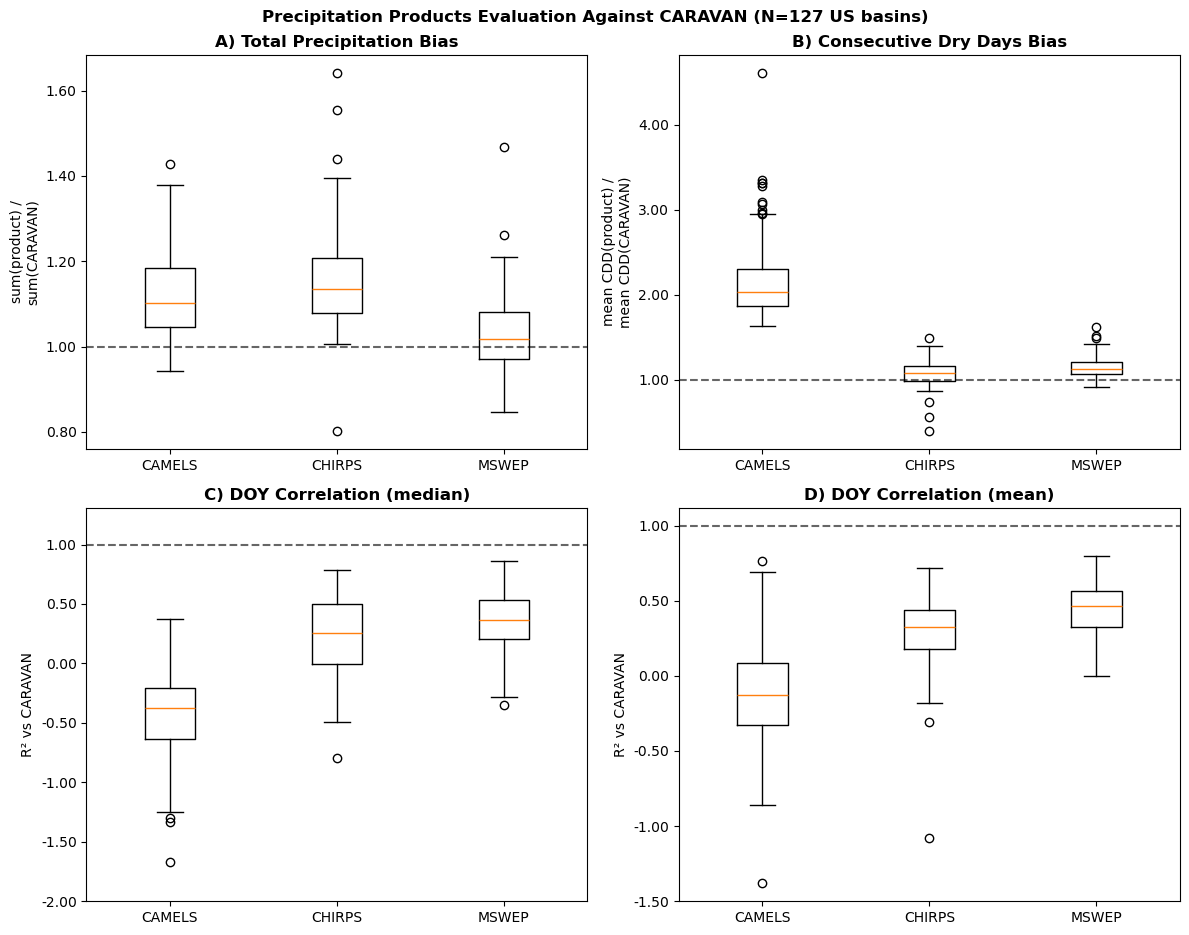

In [30]:
START_DATE = "1989-10-01"
END_DATE   = "2014-09-30"

# PRODUCTS = ["CAMELS", "CHIRPS", "CHIRPS_v3", "MSWEP"]

PRODUCTS = ["CAMELS", "CHIRPS", "MSWEP"]


VAR_MAP  = {
    "CAMELS": "camels_precipitation",
    "CARAVAN": "total_precipitation_sum",
    "CHIRPS":  "chirps_precipitation",
    # "CHIRPS_v3":  "chirps_v3_precipitation",
    "MSWEP":   "mswep_precipitation",
}
PALETTE = {
    "CAMELS": "#FF6B00", #"#3A86FF",
    "CHIRPS": "#2EC4B6",
    "MSWEP":  "#DC2626",
}

# ── Metric helpers ─────────────────────────────────────────────────────────────
def volume_ratio(arr, ref):
    s = np.nansum(ref)
    return np.nansum(arr) / s if s > 0 else np.nan

def p95_ratio(arr, ref):
    p = np.nanpercentile(ref, 95)
    return np.nanpercentile(arr, 95) / p if p > 0 else np.nan

def mean_dry_spell(arr):
    arr_clean = arr[~np.isnan(arr)]
    mask   = arr_clean == 0
    diff   = np.diff(mask.astype(int))
    starts = np.where(diff ==  1)[0] + 1
    ends   = np.where(diff == -1)[0] + 1
    if mask[0]:  starts = np.r_[0, starts]
    if mask[-1]: ends   = np.r_[ends, len(mask)]
    lengths = (ends - starts)
    lengths = lengths[lengths > 0]
    return np.mean(lengths) if len(lengths) > 0 else np.nan

def dry_spell_ratio(arr, ref):
    m_ref = mean_dry_spell(ref)
    m_arr = mean_dry_spell(arr)
    return m_arr / m_ref if (m_ref and not np.isnan(m_ref) and m_ref > 0) else np.nan

def seasonal_median(arr, dates):
    df = pd.DataFrame({"doy": pd.DatetimeIndex(dates).dayofyear, "val": arr})
    med = df.groupby("doy")["val"].median()
    full = pd.Series(0.0, index=np.arange(1, 366))
    full.update(med)
    return full.values

def seasonal_corr(arr, ref, dates):
    s_ref = seasonal_median(ref, dates)
    s_arr = seasonal_median(arr, dates)
    if np.std(s_ref) == 0:
        return np.nan
    return r2_score(s_ref, s_arr)

def seasonal_mean(arr, dates):
    df = pd.DataFrame({"doy": pd.DatetimeIndex(dates).dayofyear, "val": arr})
    mn = df.groupby("doy")["val"].mean()
    full = pd.Series(0.0, index=np.arange(1, 366))
    full.update(mn)
    return full.values

def seasonal_corr_mean(arr, ref, dates):
    s_ref = seasonal_mean(ref, dates)
    s_arr = seasonal_mean(arr, dates)
    if np.std(s_ref) == 0:
        return np.nan
    return r2_score(s_ref, s_arr)

# ── Load gauge txt ─────────────────────────────────────────────────────────────
def load_gauge_txt(basin, data_camels):
    number    = basin.split("_")[-1]
    csv_files = list(data_camels.glob(f"**/{number}*.txt"))
    if not csv_files:
        return None
    df = pd.read_csv(csv_files[0], skiprows=3, sep=r"\s+")
    df["date"] = pd.to_datetime(
        df[["Year", "Mnth", "Day"]].rename(
            columns={"Year": "year", "Mnth": "month", "Day": "day"}
        )
    )
    return df.set_index("date")["prcp(mm/day)"]

# ── Load basin list ────────────────────────────────────────────────────────────
basins_to_use = set(basins_path.read_text().splitlines())

# ── Load all basins → tidy DataFrame ──────────────────────────────────────────
records  = []
nc_files = [f for f in sorted(extended_dataset_dir.glob("*.nc"))
            if f.stem in basins_to_use]
print(f"Found {len(nc_files)} basins matching filter.")

for nc_path in nc_files:
    basin = nc_path.stem
    try:
        ds    = xr.open_dataset(nc_path).sel(date=slice(START_DATE, END_DATE))
        dates = pd.to_datetime(ds["date"].values)
        ref   = ds[VAR_MAP["CARAVAN"]].values.flatten().astype(float)
        if np.nansum(ref) == 0:
            continue

        gauge_series = load_gauge_txt(basin, data_camels)
        if gauge_series is None:
            continue
        camels_da = xr.DataArray(
            gauge_series,
            coords={"date": gauge_series.index},
            dims="date",
        ).sel(date=slice(START_DATE, END_DATE))

        arrays = {
            "CAMELS": ds[VAR_MAP["CAMELS"]].values.flatten().astype(float), #camels_da.values.flatten().astype(float),
            "CHIRPS": ds[VAR_MAP["CHIRPS"]].values.flatten().astype(float),
            # "CHIRPS_v3": ds[VAR_MAP["CHIRPS_v3"]].values.flatten().astype(float),
            "MSWEP":  ds[VAR_MAP["MSWEP"]].values.flatten().astype(float),
        }

        for prod, arr in arrays.items():
            records.append({
                "basin":     basin,
                "product":   prod,
                "vol":       volume_ratio(arr, ref),
                # "p95":       p95_ratio(arr, ref),
                "dry":       dry_spell_ratio(arr, ref),
                "seas":      seasonal_corr(arr, ref, dates),
                "seas_mean": seasonal_corr_mean(arr, ref, dates),
            })

    except Exception as e:
        print(f"  Skipping {basin}: {e}")

df = pd.DataFrame(records)
n_basins = df["basin"].nunique()
print(f"Processed {n_basins} basins.")

# ── Panel config ───────────────────────────────────────────────────────────────
PANEL_CFG = [
    ("vol",       "A) Total Precipitation Bias",      "sum(product) /\nsum(CARAVAN)"),
    # ("p95",       "B) P95 Precipitation Bias",        "P95(product) / P95(CARAVAN)"),
    ("dry",       "B) Consecutive Dry Days Bias",     "mean CDD(product) /\nmean CDD(CARAVAN)"),
    ("seas",      "C) DOY Correlation (median)", "R² vs CARAVAN"),
    ("seas_mean", "D) DOY Correlation (mean)",   "R² vs CARAVAN"),
]

# ── Plot (2×3 grid, middle bottom slot hidden) ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# fig, axes = plt.subplots(2, 2, figsize=(6, 5)) #for poster

fig.suptitle(f"Precipitation Products Evaluation Against CARAVAN (N={n_basins} US basins)",
             fontsize=12, fontweight="bold")

plot_axes = axes.flatten() 

# axes[1, 2].set_visible(False)

# plot_axes = [axes[0,0], axes[0,1], axes[0,2], axes[1,0], axes[1,1]]

for ax, (col, title, ylabel) in zip(plot_axes, PANEL_CFG):
    # sns.violinplot(
    #     data=df, x="product", y=col,
    #     hue="product", legend=False,
    #     palette=PALETTE, order=PRODUCTS,
    #     inner="box",
    #     inner_kws={"box_width": 12, "whis_width": 2},
    #     alpha=0.35, saturation=0.9,
    #     ax=ax,
    # )
    # ax.axhline(1.0, color="black", lw=1.5, ls="--", alpha=0.6)
    # ax.set_title(title, fontweight="bold")
    # ax.set_ylabel(ylabel)
    # ax.set_xlabel("")

    data_by_product = [df[df["product"] == p][col].dropna().values for p in PRODUCTS]
    
    ax.boxplot(data_by_product, tick_labels=PRODUCTS) 
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))  # 2 decimal places

    ax.axhline(1.0, color="black", lw=1.5, ls="--", alpha=0.6)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")

axes[1, 0].set_ylim(bottom=-2)
# legend_handles = [Patch(color=PALETTE[p], label=p, alpha=0.35) for p in PRODUCTS]
# fig.legend(handles=legend_handles, loc="lower center", ncol=4,
#            fontsize=10, bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## Dry ratio

In [13]:
attributes = pd.read_csv(
    "/inputs/data_updated_2/attributes/attributes_other.csv"
).set_index("gauge_id")

In [14]:
with open(basins_path, "r") as f:
    basins = [b.strip() for b in f if b.strip()]

results = []

for basin_id in basins:
    # camels_id = basin_id.replace("camels_", "")

    # --- Open CARAVAN ---
    caravan_file = data_caravan_2 / f"{basin_id}.nc"
    if not caravan_file.exists():
        print(f"No CARAVAN file for {basin_id}")
        continue

    caravan = xr.open_dataset(caravan_file)

    # --- Build xarray objects ---
    precip_caravan = caravan["total_precipitation_sum"]
    precip_camels = caravan["camels_precipitation"]
    precip_chirps = caravan["chirps_precipitation"]
    precip_mswep = caravan["mswep_precipitation"]

    # --- Align ---
    pr_car, pr_cam, pr_chirps, pr_mswep= xr.align(
        precip_caravan,
        precip_camels,
        precip_chirps,
        precip_mswep,
        join="inner"
    )

    # --- Time window ---
    pr_car = pr_car.sel(date=slice("1989-10-01", "2014-09-30"))
    pr_cam = pr_cam.sel(date=slice("1989-10-01", "2014-09-30"))
    pr_chirps = pr_chirps.sel(date=slice("1989-10-01", "2014-09-30"))
    pr_mswep = pr_mswep.sel(date=slice("1989-10-01", "2014-09-30"))

    # --- Remove NaNs ---
    mask = ~np.isnan(pr_car)
    pr_car = pr_car[mask]
    pr_cam = pr_cam[mask]
    pr_chirps = pr_chirps[mask]
    pr_mswep = pr_mswep[mask]

    # # --- Dry-day ratios ---
    # dry_caravan_ratio = float((pr_car < 0.1).sum() / pr_car.size)
    # dry_camels_ratio  = float((pr_cam < 0.1).sum() / pr_cam.size)
    # dry_chirps_ratio = float((pr_chirps < 0.1).sum() / pr_chirps.size)
    # dry_mswep_ratio  = float((pr_mswep < 0.1).sum() / pr_mswep.size)

    if basin_id in attributes.index:
        gauge_lat = attributes.loc[basin_id, "gauge_lat"]
        gauge_lon = attributes.loc[basin_id, "gauge_lon"]
    else:
        gauge_lat = np.nan
        gauge_lon = np.nan

    results.append({
        "basin": basin_id,
        "dry_ratio_caravan": float((pr_car < 0.1).sum() / pr_car.size),
        "dry_ratio_camels": float((pr_cam < 0.1).sum() / pr_cam.size),
        "dry_ratio_chirps": float((pr_chirps < 0.1).sum() / pr_chirps.size),
        "dry_ratio_mswep": float((pr_mswep < 0.1).sum() / pr_mswep.size),
        "gauge_lat": gauge_lat,
        "gauge_lon": gauge_lon,
    })

    caravan.close()

In [15]:
df_results = pd.DataFrame(results)

gdf = gpd.GeoDataFrame(
    df_results,
    geometry=gpd.points_from_xy(
        df_results["gauge_lon"],
        df_results["gauge_lat"]
    ),
    crs="EPSG:4326"
)

# Convert to Web Mercator for basemap
gdf_web = gdf.to_crs(epsg=3857)

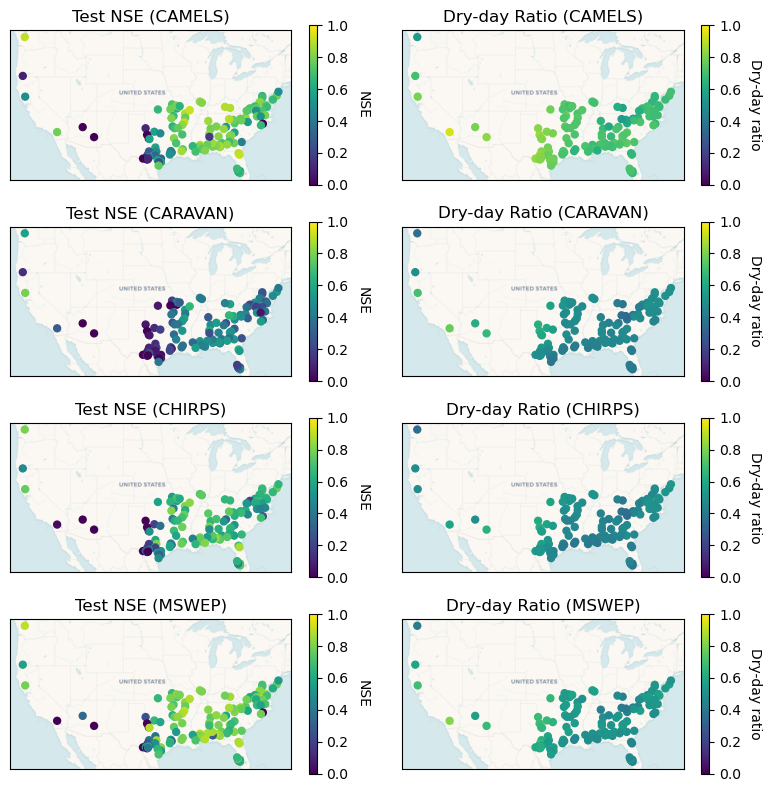

In [16]:
# --- Config ---
CONUS_BOUNDS = box(-125, 24, -66.5, 50)
conus_gdf_web = gpd.GeoDataFrame(geometry=[CONUS_BOUNDS], crs="EPSG:4326").to_crs(epsg=3857)
xmin, ymin, xmax, ymax = conus_gdf_web.total_bounds

RUN_PREFIXES = [
    "camels_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5", #CAMELS
    "total_precipitation_sum_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5", #CARAVAN
    # "chirps_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5_seed111_1304_051414", #CHIRPS
    "chirps_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5", #CHIRPS_v3
    "mswep_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5" #MSWEP
]

plot_configs = [
    ("dry_ratio_camels", "CAMELS", RUN_PREFIXES[0]),
    ("dry_ratio_caravan", "CARAVAN", RUN_PREFIXES[1]),
    ("dry_ratio_chirps",  "CHIRPS",  RUN_PREFIXES[2]),
    # ("dry_ratio_chirps_v3",  "CHIRPS",  RUN_PREFIXES[2]),
    ("dry_ratio_mswep",   "MSWEP",   RUN_PREFIXES[3]),
]

# --- Load NSE data helper ---
def load_nse_gdf(run_prefix):
    file_path = test_metrics / f"{run_prefix}.csv" #f"../runs/{run_prefix}/validation/model_epoch030/validation_results.p"
    # with open(file_path, "rb") as f:
    #     data = pickle.load(f)

    # nse_map = {catchment: data[catchment]["1D"]["NSE"] for catchment in data}

    data = pd.read_csv(file_path)
    nse_map = dict(zip(data["basin_id"], data["NSE"]))

    # attributes = pd.read_csv(location_file)

    # is_camels = "camels" in run_prefix
    # nse_map = {
    #     (f"camels_{c}" if is_camels else c): data[c]["1D"]["NSE"]
    #     for c in data
    # }

    # print(nse_map)

    attributes = pd.read_csv(location_file)

    gdf = gpd.GeoDataFrame(
        attributes,
        geometry=gpd.points_from_xy(attributes["gauge_lon"], attributes["gauge_lat"]),
        crs="EPSG:4326"
    )

    gdf["NSE"] = gdf["gauge_id"].map(nse_map)
    gdf = gdf.dropna(subset=["NSE"])
    return gdf.to_crs(epsg=3857)

# --- Plot ---
fig, ax = plt.subplots(4, 2, figsize=(8, 8))

for row, (dry_col, label, run_prefix) in enumerate(plot_configs):

    # --- Left: NSE map ---
    nse_gdf = load_nse_gdf(run_prefix)
    median_nse = nse_gdf["NSE"].median()

    nse_gdf.plot(
        column="NSE",
        cmap="viridis",
        legend=True,
        markersize=25,
        ax=ax[row, 0],
        vmin=0,
        vmax=1,
    )
    fig.axes[-1].set_ylabel(f"NSE", rotation=270, labelpad=15)
    # ax[row, 0].set_xlim(xmin, xmax)
    # ax[row, 0].set_ylim(ymin, ymax)
    cx.add_basemap(ax[row, 0], source=cx.providers.CartoDB.Voyager, attribution=False)
    ax[row, 0].set_title(f"Test NSE ({label})")
    ax[row, 0].set_xticks([])
    ax[row, 0].set_yticks([])

    # --- Right: Dry-day ratio map ---
    gdf_web.plot(
        column=dry_col,
        cmap="viridis",
        legend=True,
        markersize=25,
        ax=ax[row, 1],
        vmin=0,
        vmax=1,
    )
    fig.axes[-1].set_ylabel(f"Dry-day ratio", rotation=270, labelpad=15)
    # ax[row, 1].set_xlim(xmin, xmax)
    # ax[row, 1].set_ylim(ymin, ymax)
    cx.add_basemap(ax[row, 1], source=cx.providers.CartoDB.Voyager, attribution=False)
    ax[row, 1].set_title(f"Dry-day Ratio ({label})")
    ax[row, 1].set_xticks([])
    ax[row, 1].set_yticks([])

plt.tight_layout()
plt.show()

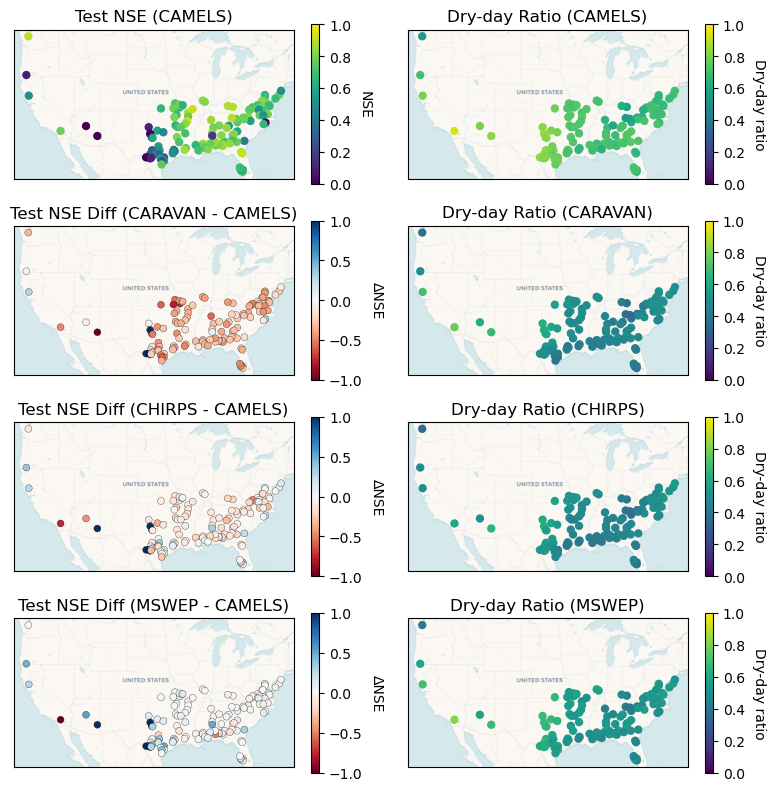

In [27]:
# --- Config ---
CONUS_BOUNDS = box(-125, 24, -66.5, 50)
conus_gdf_web = gpd.GeoDataFrame(geometry=[CONUS_BOUNDS], crs="EPSG:4326").to_crs(epsg=3857)
xmin, ymin, xmax, ymax = conus_gdf_web.total_bounds

RUN_PREFIXES = [
    "camels_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5", #CAMELS
    "total_precipitation_sum_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5", #CARAVAN
    # "chirps_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5_seed111_1304_051414", #CHIRPS
    "chirps_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5", #CHIRPS_v3
    "mswep_precipitation_seq_270_1_epochs_30_hidden_256_dropout_04_fb_5" #MSWEP
]

plot_configs = [
    ("dry_ratio_camels", "CAMELS", RUN_PREFIXES[0]),
    ("dry_ratio_caravan", "CARAVAN", RUN_PREFIXES[1]),
    ("dry_ratio_chirps",  "CHIRPS",  RUN_PREFIXES[2]),
    ("dry_ratio_mswep",   "MSWEP",   RUN_PREFIXES[3]),
]

# --- Load NSE data helper ---
def load_nse_gdf(run_prefix):
    file_path = test_metrics / f"{run_prefix}.csv"
    data = pd.read_csv(file_path)
    nse_map = dict(zip(data["basin_id"], data["NSE"]))
    attributes = pd.read_csv(location_file)
    gdf = gpd.GeoDataFrame(
        attributes,
        geometry=gpd.points_from_xy(attributes["gauge_lon"], attributes["gauge_lat"]),
        crs="EPSG:4326"
    )
    gdf["NSE"] = gdf["gauge_id"].map(nse_map)
    gdf = gdf.dropna(subset=["NSE"])
    return gdf.to_crs(epsg=3857)

# --- Load CAMELS NSE as reference ---
camels_gdf = load_nse_gdf(RUN_PREFIXES[0])
camels_nse = dict(zip(camels_gdf["gauge_id"], camels_gdf["NSE"]))

# --- Plot ---
fig, ax = plt.subplots(4, 2, figsize=(8, 8))

for row, (dry_col, label, run_prefix) in enumerate(plot_configs):

    nse_gdf = load_nse_gdf(run_prefix)

    # --- Left: NSE for CAMELS, ΔNSE vs CAMELS for others ---
    if label == "CAMELS":
        nse_gdf.plot(
            column="NSE",
            cmap="viridis",
            legend=True,
            markersize=25,
            ax=ax[row, 0],
            vmin=0,
            vmax=1,
        )
        fig.axes[-1].set_ylabel("NSE", rotation=270, labelpad=15)
        ax[row, 0].set_title(f"Test NSE ({label})")
    else:
        nse_gdf["NSE_diff"] = nse_gdf["NSE"] - nse_gdf["gauge_id"].map(camels_nse)
        nse_gdf_diff = nse_gdf.dropna(subset=["NSE_diff"])
        nse_gdf_diff.plot(
            column="NSE_diff",
            cmap="RdBu",
            legend=True,
            markersize=25,
            ax=ax[row, 0],
            vmin=-1,
            vmax=1,
            edgecolors="black",
            linewidths=0.2,
        )
        fig.axes[-1].set_ylabel("ΔNSE", rotation=270, labelpad=15)
        ax[row, 0].set_title(f"Test NSE Diff ({label} - CAMELS)")

    cx.add_basemap(ax[row, 0], source=cx.providers.CartoDB.Voyager, attribution=False)
    ax[row, 0].set_xticks([])
    ax[row, 0].set_yticks([])

    # --- Right: Dry-day ratio map ---
    gdf_web.plot(
        column=dry_col,
        cmap="viridis",
        legend=True,
        markersize=25,
        ax=ax[row, 1],
        vmin=0,
        vmax=1,
    )
    fig.axes[-1].set_ylabel("Dry-day ratio", rotation=270, labelpad=15)
    cx.add_basemap(ax[row, 1], source=cx.providers.CartoDB.Voyager, attribution=False)
    ax[row, 1].set_title(f"Dry-day Ratio ({label})")
    ax[row, 1].set_xticks([])
    ax[row, 1].set_yticks([])

plt.tight_layout()
plt.show()

# Map

In [17]:
gdf_web

,basin,dry_ratio_caravan,dry_ratio_camels,dry_ratio_chirps,dry_ratio_mswep,gauge_lat,gauge_lon,geometry
0,camels_01411300,0.498302,0.698938,0.511554,0.561822,39.30694,-74.82056,POINT (-8328986.64 4765733.948)
1,camels_01466500,0.494907,0.700142,0.532800,0.511773,39.88500,-74.50528,POINT (-8293889.831 4849244.839)
2,camels_01487000,0.501917,0.682291,0.518454,0.538495,38.72833,-75.56186,POINT (-8411507.779 4682831.549)
3,camels_01638480,0.500712,0.666521,0.488446,0.545285,39.25455,-77.57638,POINT (-8635763.119 4758199.543)
4,camels_01644000,0.498302,0.656664,0.487022,0.525901,39.01955,-77.57749,POINT (-8635886.684 4724472.329)
...,...,...,...,...,...,...,...,...
122,camels_09505800,0.622495,0.794984,0.498631,0.573431,34.53864,-111.69404,POINT (-12433723.657 4101359.579)
123,camels_10259000,0.766400,0.935385,0.584492,0.814916,33.76002,-116.55002,POINT (-12974288.878 3996623.914)
124,camels_11451100,0.701457,0.793889,0.488336,0.692805,39.16545,-122.61999,POINT (-13649994.848 4745398.651)
125,camels_12073500,0.366773,0.549228,0.354178,0.414851,47.38926,-122.69902,POINT (-13658792.427 6005844.287)


In [18]:
basin_biggest_drop = "camels_03604000"

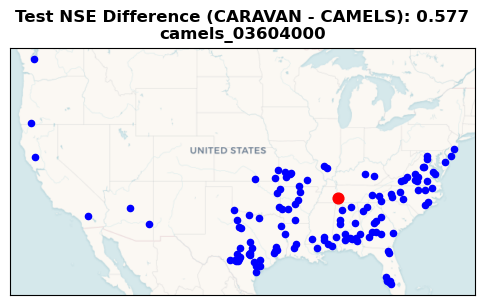

In [29]:
gdf_target = gdf_web[gdf_web["basin"] == basin_biggest_drop]
gdf_others = gdf_web[gdf_web["basin"] != basin_biggest_drop]

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

gdf_others.plot(
    ax=ax,
    color="blue",
    markersize=20
)

gdf_target.plot(
    ax=ax,
    color="red",
    markersize=60
)

cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager, attribution=False)

# ax.set_title("Training Basins - US")
ax.set_xticks([])
ax.set_yticks([])

plt.title(f"Test NSE Difference (CARAVAN - CAMELS): 0.577\n{basin_biggest_drop}", fontweight='bold')
# plt.title(f"Location of basin: {basin_biggest_drop} - NSE drop: 0.577", fontweight='bold')

plt.show()